# Hands-on 1: Simple Linear Regression (SLR) with Python

**Materia:** Machine Learning 2026B  
**Alumno:** Yahir Valenzuela  
**Docente:** José Antonio Aviña Méndez  

## Objetivo

Analizar la Regresión Lineal Simple y las clases, funciones, métodos y atributos empleados para su implementación en Python y Scikit-learn, siguiendo el desarrollo del artículo de Ebrahim Mousavi.

## 1. Fundamentos de la técnica SLR

La **Regresión Lineal Simple (SLR)** modela la relación entre una variable independiente \(x\) y una variable dependiente \(y\). El objetivo es encontrar una recta que describa la tendencia de los datos y permita estimar nuevos valores de la variable dependiente.

En el entrenamiento, los parámetros de la recta se ajustan para reducir la diferencia entre los valores observados y los valores predichos.

## 2. Modelo matemático

<div style="background:#f8f9ff; border:1px solid #d9def7; border-radius:14px; padding:18px; margin:12px 0;">
  <h3 style="margin-top:0; color:#2c3e50;">Función de predicción</h3>
  <p>La regresión lineal simple estima la variable dependiente mediante una recta:</p>

$$
\hat{y}=wx+b
$$

  <p>donde:</p>
  <ul>
    <li><b>x</b>: variable independiente.</li>
    <li><b>\hat{y}</b>: valor predicho.</li>
    <li><b>w</b> o <b>\beta_1</b>: pendiente o coeficiente.</li>
    <li><b>b</b> o <b>\beta_0</b>: intercepto.</li>
    <li><b>y</b>: valor real de la variable dependiente.</li>
  </ul>
</div>

<div style="background:#fffaf2; border:1px solid #f0d9a7; border-radius:14px; padding:18px; margin:12px 0;">
  <h3 style="margin-top:0; color:#7a4e00;">Función de pérdida MSE</h3>
  <p>Una medida de error utilizada en regresión es el <b>Mean Squared Error (MSE)</b>, que cuantifica la diferencia entre los valores reales y los valores predichos:</p>

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2
$$

  <p>Mientras menor sea el valor del MSE, mejor es el ajuste del modelo a los datos observados.</p>
</div>

### Implementación básica de SLR y MSE

`import numpy as np` incorpora NumPy para trabajar con arreglos y operaciones numéricas.  
`predict(x, w, b)` implementa la ecuación lineal \(wx+b\).  
`mse_loss(y_pred, y_true)` calcula el promedio de los errores al cuadrado.  
`x` contiene las entradas, `y_true` los valores reales, y `w` y `b` representan la pendiente y el intercepto usados en este ejemplo.  
Después se calculan `y_pred` y `loss`, y se imprimen ambos resultados.

In [1]:
import numpy as np  

def predict(x, w, b):  
    return w * x + b  

def mse_loss(y_pred, y_true):  
    return np.mean((y_pred - y_true) ** 2)  

# Example data  
x = np.array([1, 2, 3, 4, 5])       # Input data (independent variable)  
y_true = np.array([2, 4, 5, 4, 5])  # True output data (dependent variable)  

# Model parameters (slope and intercept)  
w = 0.8  
b = 1.0  

# Predict outputs  
y_pred = predict(x, w, b)  

# Calculate MSE loss  
loss = mse_loss(y_pred, y_true)  

print(f"Predicted values: {y_pred}")  
print(f"MSE Loss: {loss:.3f}")

# Predicted values: [1.8 2.6 3.4 4.2 5.]
# MSE Loss: 0.920

Predicted values: [1.8 2.6 3.4 4.2 5. ]
MSE Loss: 0.920


### Creación de los datos de Engine Size y CO₂

Pandas se usa para construir el DataFrame, NumPy para generar los valores y Matplotlib para las gráficas.  
`np.random.seed(42)` permite reproducir el mismo ruido aleatorio.  
`engine_sizes` contiene 100 tamaños de motor entre 1.5 y 4.5.  
`slope` e `intercept` definen la relación lineal y `noise` agrega variación.  
`co2_emissions` es la variable dependiente generada a partir del tamaño del motor.

In [2]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  

np.random.seed(42) 

# Generate realistic engine sizes and corresponding CO2 emissions 
# 100 engine sizes from 1.5 to 4.5 
engine_sizes = np.linspace(1.5, 4.5, 100)   
slope = 60  
intercept = 50  

# Adding random noise
noise = np.random.normal(0, 15, size=engine_sizes.shape)  
co2_emissions = slope * engine_sizes + intercept + noise  

# Create a DataFrame  
df = pd.DataFrame({'Engine_size': engine_sizes,  
                   'CO2_Emissions': co2_emissions})

df.head()  

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-sgy_pfe_ because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,Engine_size,CO2_Emissions
0,1.500000,147.450712
1,1.530303,139.744217
2,1.560606,153.351692
3,1.590909,168.299993
4,1.621212,143.760427


### Visualización de Engine Size vs. CO₂ Emissions

`plt.scatter()` representa cada par de observaciones.  
El eje X corresponde a `Engine_size` y el eje Y a `CO2_Emissions`.  
Las etiquetas, el título y la cuadrícula facilitan la interpretación de la relación entre ambas variables.

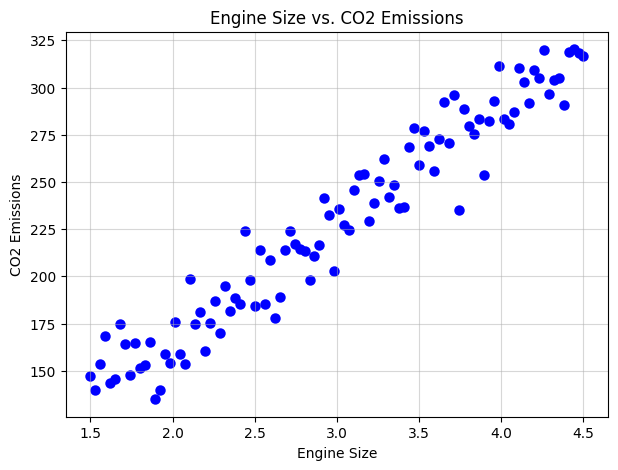

In [3]:
plt.figure(figsize=(7, 5))  
plt.scatter(df['Engine_size'], df['CO2_Emissions'], 
            color='b', edgecolors='b', linewidths=1.5)  
plt.xlabel('Engine Size')  
plt.ylabel('CO2 Emissions')  
plt.title('Engine Size vs. CO2 Emissions')  
plt.grid(alpha=0.5)  
plt.show()

### Comparación de rectas con distintos parámetros

`params` contiene cuatro combinaciones de pendiente, intercepto y color.  
El ciclo recorre cada combinación, dibuja los datos reales y calcula la recta `y = a*x + b`.  
La comparación permite observar cómo los parámetros modifican el ajuste de una recta a los datos.

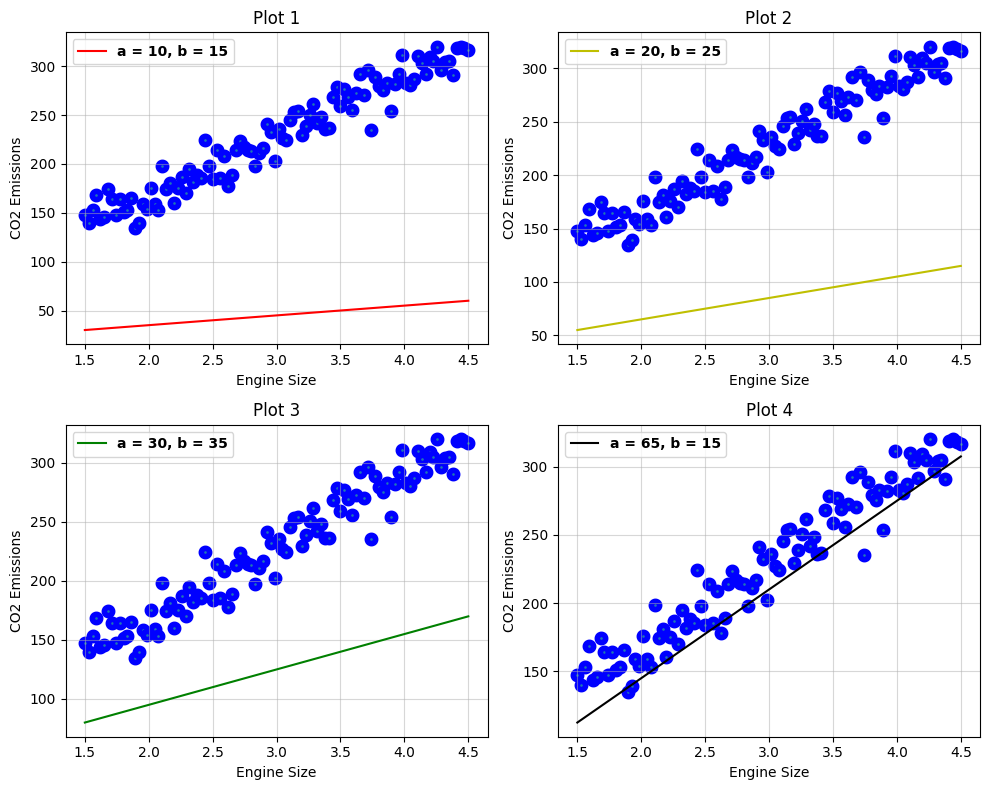

In [4]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
 
# Prepare the plot  
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  
legend_properties = {'weight': 'bold'}  

# Define the different a and b parameters for the plots  
params = [  
    (10, 15, 'r'),  
    (20, 25, 'y'),  
    (30, 35, 'g'),  
    (65, 15, 'k')  
]  

# Loop through and create each subplot  
for i, ax in enumerate(axs.flatten()):  
    a, b, color = params[i]  
    x = np.linspace(1.5, 4.5, 100)  # Define the range for Engine_size  
    
    # Scatter plot  
    x_scatter = df['Engine_size']  
    y_scatter = df['CO2_Emissions']  
    ax.scatter(x_scatter, y_scatter, edgecolors='b', linewidths=4.)  
    
    # Linear regression line  
    y = a * x + b  
    ax.plot(x, y, color, label=f'a = {a}, b = {b}')  
    
    # Labels and grid  
    ax.set_xlabel('Engine Size')  
    ax.set_ylabel('CO2 Emissions')  
    ax.legend(prop=legend_properties)  
    ax.grid(alpha=0.5)  
    ax.set_title(f'Plot {i + 1}')  

# Adjust layout  
plt.tight_layout()  
plt.show()

### Mean Absolute Error (MAE)

`mae_loss()` recibe los valores predichos y reales.  
Primero valida que ambos sean arreglos de NumPy, que tengan la misma forma y que no estén vacíos.  
Después calcula el promedio del valor absoluto de los errores mediante `np.mean(np.abs(...))`.

In [5]:
import numpy as np

def mae_loss(y_pred, y_true):
    """
    Compute the Mean Absolute Error (MAE) between predicted and true values.

    Parameters:
    y_pred (numpy.ndarray): Predicted values.
    y_true (numpy.ndarray): True values.

    Returns:
    float: The Mean Absolute Error.

    Raises:
    ValueError: If inputs are not NumPy arrays or have mismatched shapes.
    """
    # Input validation
    if not isinstance(y_pred, np.ndarray) or not isinstance(y_true, np.ndarray):
        raise ValueError("Inputs must be NumPy arrays.")
    
    if y_pred.shape != y_true.shape:
        raise ValueError("Input arrays must have the same shape.")
    
    if y_true.size == 0:
        raise ValueError("Input arrays must not be empty.")
    
    # Compute the Mean Absolute Error
    loss = np.mean(np.abs(y_pred - y_true))
    
    return loss

### Ejemplo de uso de MAE

Se definen arreglos con valores reales y predichos.  
`mae_loss(y_pred, y_true)` calcula el error absoluto medio y el resultado se imprime para interpretar la magnitud promedio del error.

In [6]:
# Example data
y_true = np.array([3.0, -0.5, 2.0, 7.0])  # Actual values
y_pred = np.array([2.5, 0.0, 2.0, 8.0])   # Predicted values

# Calculate MAE
loss = mae_loss(y_pred, y_true)

print(f"MAE Loss: {loss}")
# MAE Loss: 0.5

MAE Loss: 0.5


### Validación de entradas de MAE

Este ejemplo utiliza listas de Python en vez de arreglos NumPy.  
El bloque `try/except` permite observar la validación implementada por `mae_loss()` cuando las entradas no cumplen el tipo esperado.

In [7]:
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

try:
    loss = mae_loss(y_pred, y_true)
except ValueError as e:
    print(f"Error: {e}")

Error: Inputs must be NumPy arrays.


### Mean Squared Error (MSE)

`mse_loss()` aplica las mismas validaciones de entrada y calcula el promedio de los errores elevados al cuadrado.  
Al elevar los errores al cuadrado, las diferencias grandes reciben una penalización mayor.

In [8]:
import numpy as np

def mse_loss(y_pred, y_true):
    """
    Compute the Mean Squared Error (MSE) between predicted and true values.

    Parameters:
    y_pred (numpy.ndarray): Predicted values.
    y_true (numpy.ndarray): True values.

    Returns:
    float: The Mean Squared Error.

    Raises:
    ValueError: If inputs are not NumPy arrays or have mismatched shapes.
    """
    # Input validation
    if not isinstance(y_pred, np.ndarray) or not isinstance(y_true, np.ndarray):
        raise ValueError("Inputs must be NumPy arrays.")
    
    if y_pred.shape != y_true.shape:
        raise ValueError("Input arrays must have the same shape.")
    
    if y_true.size == 0:
        raise ValueError("Input arrays must not be empty.")
    
    # Compute the Mean Squared Error
    loss = np.mean((y_pred - y_true) ** 2)
    
    return loss

### Ejemplo de uso de MSE

Se proporcionan valores reales y predichos, se llama a `mse_loss()` y se muestra el resultado obtenido.

In [9]:
# Example data
y_true = np.array([3.0, -0.5, 2.0, 7.0])  # Actual values
y_pred = np.array([2.5, 0.0, 2.0, 8.0])   # Predicted values

# Calculate MSE
loss = mse_loss(y_pred, y_true)
print(f"MSE Loss: {loss}")

# MSE Loss: 0.375

MSE Loss: 0.375


### Comparación visual de MAE y MSE

Se generan errores entre -1 y 1.  
`np.square()` representa la penalización cuadrática del MSE y `np.abs()` la penalización absoluta del MAE.  
Ambas curvas se grafican para comparar su comportamiento.

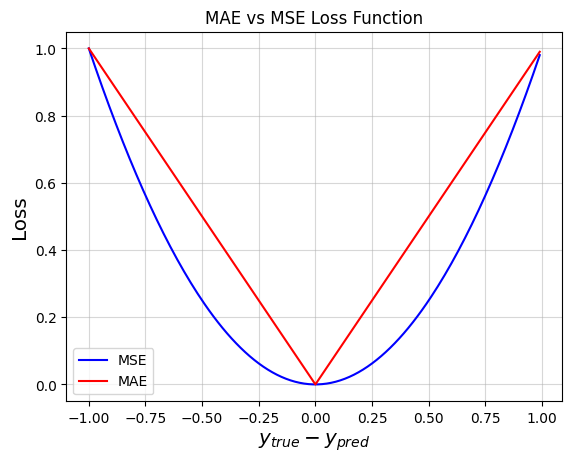

In [10]:
import numpy as np  
import matplotlib.pylab as plt  

# Plot MSE  
x_mse = np.arange(-1, 1, 0.01)  
y_mse = np.square(x_mse)  
plt.plot(x_mse, y_mse, "blue", label="MSE")  
plt.grid(True, which="major", alpha=0.5)  

# Plot MAE  
x_mae = np.arange(-1, 1, 0.01)  
y_mae = np.abs(x_mae)  
plt.plot(x_mae, y_mae, "red", label="MAE")  
plt.grid(True, which="major", alpha=0.5)  

# Labels and title  
plt.xlabel('$y_{true} - y_{pred}$', size='x-large')  
plt.ylabel('Loss', size='x-large')  
plt.title('MAE vs MSE Loss Function')  
plt.legend()  

# Show the plot  
plt.show()

### MAE y MSE con Scikit-learn

`mean_absolute_error` y `mean_squared_error` son funciones de `sklearn.metrics`.  
Reciben los valores reales y predichos y devuelven las métricas MAE y MSE, respectivamente.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error  

# Example true and predicted values  
y_true = [2, 4, 5, 4, 5]   
y_pred = [2.5, 3.8, 4.5, 4.2, 5.1]    

# Calculate MAE  
mae = mean_absolute_error(y_true, y_pred)  
print(f"Mean Absolute Error (MAE): {mae}")  

# Calculate MSE  
mse = mean_squared_error(y_true, y_pred)  
print(f"Mean Squared Error (MSE): {mse}")

Mean Absolute Error (MAE): 0.3
Mean Squared Error (MSE): 0.118


### R-Squared con Scikit-learn

`r2_score()` compara valores reales y predichos.  
R² indica qué proporción de la variabilidad de la variable objetivo es explicada por las predicciones del modelo.

In [12]:
from sklearn.metrics import r2_score

# Actual values
actual = [1, 2, 3, 4, 5]

# Predicted values
predicted = [1.2, 1.8, 3.2, 3.9, 4.7]

# Compute R-Squared score
r2 = r2_score(actual, predicted)

print("R-Squared score:", r2)
# R-Squared score: 0.978

R-Squared score: 0.978


### Imports para el entrenamiento con Advertising

Pandas carga y manipula el dataset.  
NumPy se utiliza para convertir los datos a arreglos que posteriormente se separarán en variables de entrada y salida.

In [13]:
import pandas as pd
import numpy as np

### Carga del dataset Advertising

`pd.read_csv('Datasets/Advertising.csv')` lee el archivo usado por el artículo.  
`df.iloc[:, 1:]` elimina la primera columna, que en la versión utilizada por el artículo corresponde al índice guardado en el CSV.  
`df.head()` muestra las primeras cinco observaciones.

## Acceso al dataset desde Google Drive

El archivo **Advertising.csv** debe estar guardado en:

`Mi unidad/Machine-learning/Advertising.csv`

Primero se monta Google Drive para que Colab pueda acceder al archivo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine-learning/Advertising.csv')

# remove the first column from the DataFrame.
df = df.iloc[:, 1:]

df.head()

### Selección de una característica

`df[['TV', 'Sales']]` conserva únicamente el presupuesto de publicidad en TV y las ventas.  
Esto define el problema de Regresión Lineal Simple: **TV** es la entrada y **Sales** es la salida que se desea modelar.

In [16]:
df_new = df[['TV', 'Sales']]
df_new.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


### Tipo de estructura de datos

`type(df_new)` permite comprobar que la selección anterior continúa siendo un `pandas.DataFrame`.

In [17]:
type(df_new) # pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

### Conversión a NumPy

El artículo convierte `df` a un arreglo NumPy mediante `np.array(df)`.  
Este código se conserva primero tal como aparece en la fuente.

In [18]:
dataset = np.array(df)

### Nota técnica: `df` frente a `df_new`

La secuencia anterior crea `df_new` con las columnas `TV` y `Sales`, pero el código original usa `dataset = np.array(df)`. Con esa línea, `x = dataset[:, 0]` corresponde a **TV** y `y = dataset[:, 1]` corresponde a **Radio**.

Eso no coincide con el problema SLR definido como `TV` → `Sales` ni con los coeficientes mostrados posteriormente en el artículo. Por ello la línea original permanece arriba y la siguiente celda selecciona explícitamente `df_new` para continuar con el modelo descrito.

In [19]:
dataset = np.array(df_new)

### División Train/Test

`x` toma la primera columna y `y` la segunda.  
`train_test_split(..., test_size=0.2, random_state=42)` reserva 20 % de las observaciones para prueba y 80 % para entrenamiento, manteniendo una división reproducible.  
Los `print()` muestran las dimensiones resultantes.

In [20]:
# Extract the values from array in the first column, assign them to the variable 'x'.
x = dataset[:, 0]
y = dataset[:, 1]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape) # (160,)
print(y_train.shape) # (160,)
print(x_test.shape)  # (40,)
print(y_test.shape)  # (40,)

(160,)
(160,)
(40,)
(40,)


### Visualización de los datos de entrenamiento

`plt.scatter(x_train, y_train)` permite observar la relación entre las variables antes de entrenar el modelo.

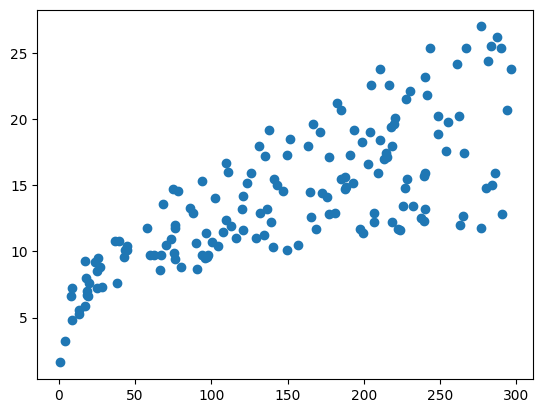

In [21]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train);

### Cambio de forma de los arreglos

`reshape(-1, 1)` convierte cada arreglo unidimensional en una matriz de una sola columna, formato esperado por `LinearRegression` para la variable de entrada.

In [22]:
x_train = x_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

### Comprobación de dimensiones

`.shape` permite verificar que los arreglos de entrenamiento quedaron con una columna.

In [23]:
x_train.shape, y_train.shape
# ((160, 1), (160, 1))

((160, 1), (160, 1))

### Creación y entrenamiento del modelo

`LinearRegression()` crea una instancia del modelo.  
`fit(x_train, y_train)` estima el coeficiente y el intercepto que minimizan el error cuadrático sobre los datos de entrenamiento.

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Coeficiente e intercepto

`model.coef_` contiene el coeficiente aprendido y `model.intercept_` contiene el intercepto.  
Estos valores corresponden a los parámetros de la ecuación \(\hat{y}=\beta_0+\beta_1x\).

In [25]:
model.coef_, model.intercept_
# 0.04652973, 7.11963843

(array([[0.04652973]]), array([7.11963843]))

### Predicción y pérdida del modelo entrenado

`model.predict(x_train)` genera predicciones para los datos de entrenamiento.  
Después se calcula manualmente el MSE mediante NumPy para medir la diferencia entre los valores reales y los predichos.

In [26]:
# Compute the predicted values
y_pred = model.predict(x_train)

# Compute the loss (mean squared error)
loss = np.mean((y_train - y_pred) ** 2)
print(loss)  # 10.60

10.603600570989268


### Gráfica de la función hipótesis

El artículo dibuja los datos de entrenamiento y una recta construida con valores aproximados de intercepto y pendiente.  
La versión textual suministrada contiene una duplicación en la llamada a `np.linspace`, por lo que se conserva abajo como referencia y se ejecuta inmediatamente después la misma instrucción sin la duplicación sintáctica.

**Código tal como aparece en el texto suministrado:**

```python
plt.scatter(x_train, y_train);

x = np.linspace(0, 300, 100)0, 300, 100)

b0 = 7.11
b1 = 0.04

y_hat = b0 + b1*x

plt.plot(x, y_hat, 'r',  label=f'b0 = {b0},  b1 = {b1}');
plt.legend()
```

### Versión ejecutable de la misma gráfica

La corrección elimina únicamente la duplicación posterior a `np.linspace(0, 300, 100)`. El resto de las instrucciones permanece igual.

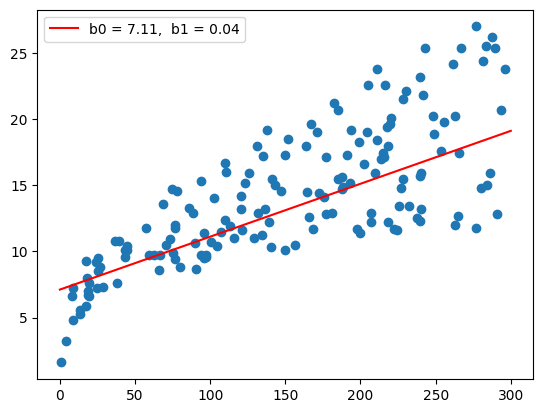

In [27]:
plt.scatter(x_train, y_train);

x = np.linspace(0, 300, 100)

b0 = 7.11
b1 = 0.04

y_hat = b0 + b1*x

plt.plot(x, y_hat, 'r',  label=f'b0 = {b0},  b1 = {b1}');
plt.legend()
plt.show()

## 4. Verificación con el conjunto de prueba

Se calculan MAE, MSE y R² sobre las observaciones reservadas para prueba.

- **MAE** mide el error absoluto promedio.
- **MSE** penaliza con mayor fuerza los errores grandes.
- **R²** indica qué proporción de la variabilidad de `Sales` es explicada por la relación lineal con `TV`.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x_test_2d = x_test.reshape(-1, 1)
y_test_pred = model.predict(x_test_2d).ravel()

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"MAE (test): {mae_test:.6f}")
print(f"MSE (test): {mse_test:.6f}")
print(f"R²  (test): {r2_test:.6f}")

MAE (test): 2.444420
MSE (test): 10.204654
R²  (test): 0.676695


## 5. Comprobación de parámetros

Los atributos `coef_` e `intercept_` permiten consultar los parámetros calculados directamente por Scikit-learn.

In [29]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[0.04652973]]
Intercept: [7.11963843]


## Conclusión

La Regresión Lineal Simple representa la relación entre una variable independiente y una variable dependiente mediante una recta. En el ejemplo final, `TV` es la entrada y `Sales` la salida. `LinearRegression.fit()` estima el coeficiente y el intercepto, mientras que `predict()` aplica la ecuación aprendida.

Las funciones MAE y MSE cuantifican el error y R² permite valorar qué proporción de la variación de las ventas queda explicada por el modelo.

## Referencias

- Mousavi, E. (2024, 12 de enero). *ML Series: Day 2 — Simple Linear Regression*. Medium. https://medium.com/@ebimsv/machine-learning-series-day-2-simple-linear-regression-46a8566a5ac4
- Scikit-learn Developers. *LinearRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Scikit-learn Developers. *train_test_split*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Scikit-learn Developers. *Regression metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- Dataset Advertising: https://gist.github.com/DainPixel/8705b4f37abddb67e56e94f0a1e565a3